# HumanForYou — Amélioration du modèle & Recommandations

**Objectif :** Améliorer le Random Forest par une optimisation des hyperparamètres, puis interpréter les résultats avec SHAP pour formuler des recommandations concrètes à la direction de HumanForYou.

Les étapes :
1. Optimisation des hyperparamètres (RandomizedSearchCV)
2. Comparaison avant / après optimisation
3. Interprétation SHAP — quels facteurs poussent les employés à partir ?
4. Recommandations finales pour HumanForYou

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection  import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, roc_auc_score,
                                      f1_score, ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

PROC = '../data/processed/'

---
## 1. Chargement et séparation des données

In [2]:
df = pd.read_csv(PROC + 'dataset_final.csv')

X = df.drop(columns=['Attrition', 'EmployeeID'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

Train : 3528 lignes | Test : 882 lignes


---
## 2. Rappel — Random Forest de base (notebook 03)

On réentraîne le modèle par défaut pour avoir une référence de comparaison.

In [3]:
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base  = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

f1_base  = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

print(f"Random Forest de base — F1 : {f1_base:.4f} | AUC : {auc_base:.4f}")

Random Forest de base — F1 : 0.9283 | AUC : 0.9952


---
## 3. Optimisation des hyperparamètres

### Qu'est-ce qu'un hyperparamètre ?
Ce sont les réglages du modèle qu'on définit **avant** l'entraînement. Par exemple :
- `n_estimators` : combien d'arbres dans la forêt ?
- `max_depth` : jusqu'où chaque arbre peut-il pousser ?
- `min_samples_split` : combien d'employés minimum pour couper une branche ?

### RandomizedSearchCV — comment ça marche ?
On lui donne une grille de valeurs possibles. Il tire **aléatoirement** des combinaisons de valeurs et évalue chacune par validation croisée. C'est plus rapide qu'un `GridSearchCV` qui testerait toutes les combinaisons.

> C'est la technique d'optimisation d'hyperparamètres mentionnée dans votre Boucle 3.

In [4]:
# Grille de paramètres à explorer
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,           # On teste 30 combinaisons aléatoires
    scoring='f1',        # On optimise le F1-score
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("\nMeilleurs hyperparamètres trouvés :")
for k, v in search.best_params_.items():
    print(f"  {k:25s} : {v}")
print(f"\nMeilleur F1 en validation croisée : {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Meilleurs hyperparamètres trouvés :
  n_estimators              : 300
  min_samples_split         : 5
  min_samples_leaf          : 2
  max_features              : sqrt
  max_depth                 : 30

Meilleur F1 en validation croisée : 0.8532


---
## 4. Comparaison avant / après optimisation

In [5]:
rf_opti = search.best_estimator_

y_pred_opti  = rf_opti.predict(X_test)
y_proba_opti = rf_opti.predict_proba(X_test)[:, 1]

f1_opti  = f1_score(y_test, y_pred_opti)
auc_opti = roc_auc_score(y_test, y_proba_opti)

print("=== Comparaison avant / après optimisation ===")
print(f"{'':35s} {'F1-score':>10} {'AUC-ROC':>10}")
print(f"{'Random Forest de base':35s} {f1_base:>10.4f} {auc_base:>10.4f}")
print(f"{'Random Forest optimisé':35s} {f1_opti:>10.4f} {auc_opti:>10.4f}")

print("\n--- Rapport complet (modèle optimisé) ---")
print(classification_report(y_test, y_pred_opti, target_names=['Reste (0)', 'Part (1)']))

=== Comparaison avant / après optimisation ===
                                      F1-score    AUC-ROC
Random Forest de base                   0.9283     0.9952
Random Forest optimisé                  0.8958     0.9924

--- Rapport complet (modèle optimisé) ---
              precision    recall  f1-score   support

   Reste (0)       0.97      1.00      0.98       740
    Part (1)       0.99      0.82      0.90       142

    accuracy                           0.97       882
   macro avg       0.98      0.91      0.94       882
weighted avg       0.97      0.97      0.97       882



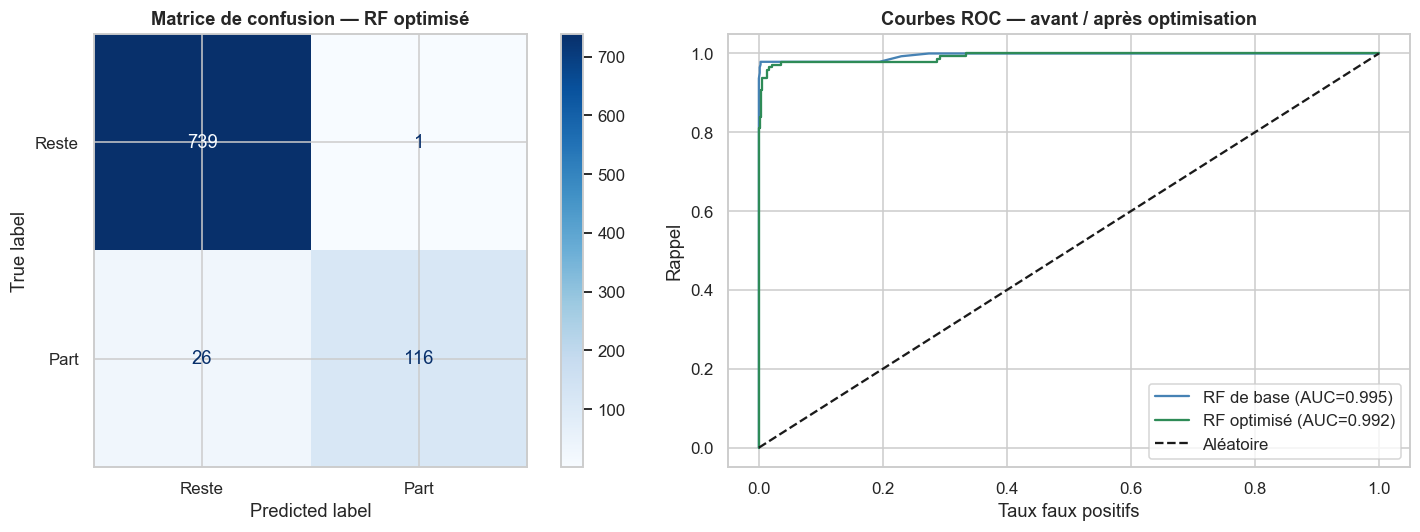

In [6]:
# Matrice de confusion + courbes ROC côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion — modèle optimisé
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opti,
    display_labels=['Reste', 'Part'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion — RF optimisé', fontweight='bold')

# Courbes ROC avant / après
for label, y_proba, color in [
    ('RF de base', y_proba_base, 'steelblue'),
    ('RF optimisé', y_proba_opti, 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)

axes[1].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Rappel')
axes[1].set_title('Courbes ROC — avant / après optimisation', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/rf_optimise_evaluation.png', bbox_inches='tight')
plt.show()

---
## 5. Interprétation SHAP

### Qu'est-ce que SHAP ?
SHAP (SHapley Additive exPlanations) répond à la question : **"Pourquoi le modèle a-t-il prédit que cet employé allait partir ?"**

Pour chaque employé, SHAP calcule la contribution de chaque variable à la prédiction. Une valeur SHAP positive pousse vers "part", une valeur négative pousse vers "reste".

C'est essentiel pour HumanForYou : ils ont besoin de comprendre **sur quels leviers agir**, pas juste savoir qu'un employé risque de partir.

In [7]:
# Calcul des valeurs SHAP (sur un échantillon de 300 pour la rapidité)
explainer   = shap.TreeExplainer(rf_opti)
X_sample    = X_test.sample(300, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Selon la version de SHAP :
# - ancienne : liste de 2 arrays (n_samples, n_features) → shap_values[1]
# - nouvelle (0.51+) : array 3D (n_samples, n_features, n_classes) → shap_values[:, :, 1]
if isinstance(shap_values, list):
    shap_part = shap_values[1]
elif shap_values.ndim == 3:
    shap_part = shap_values[:, :, 1]
else:
    shap_part = shap_values

# expected_value pour la classe "Part"
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    base_value = float(np.array(ev).flatten()[1])
else:
    base_value = float(ev)

print(f"Valeurs SHAP calculées pour {X_sample.shape[0]} employés × {X_sample.shape[1]} variables")
print(f"Shape shap_part : {shap_part.shape}")

Valeurs SHAP calculées pour 300 employés × 43 variables
Shape shap_part : (300, 43)


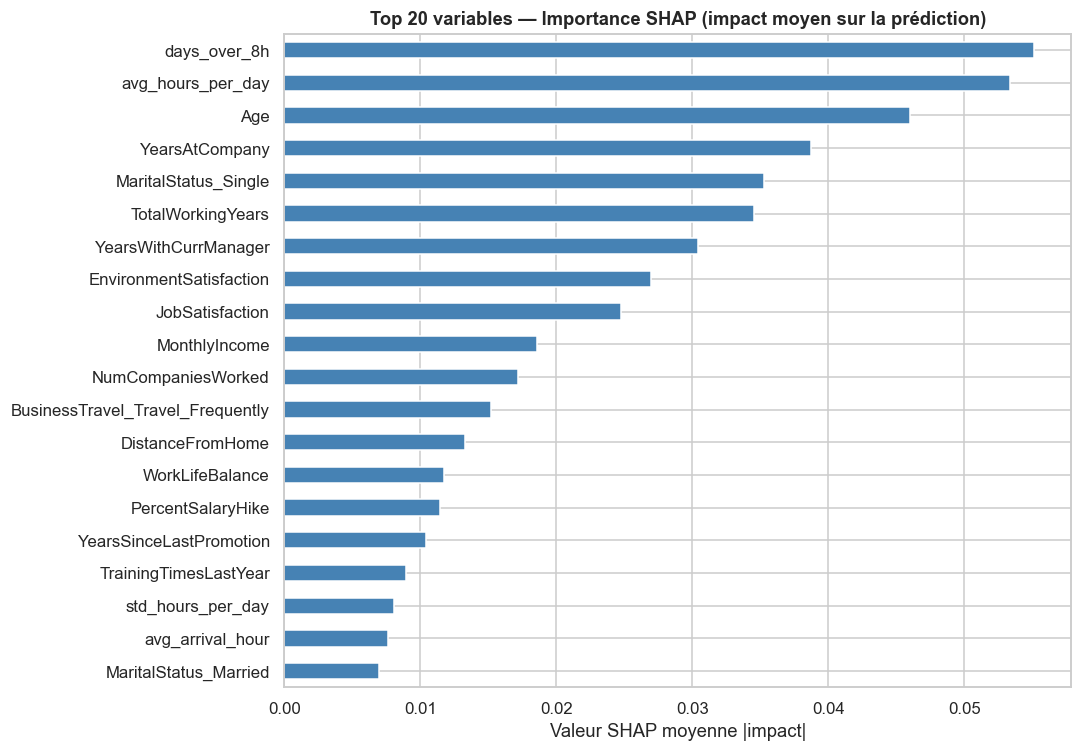

In [8]:
# Graphique 1 : importance globale (moyenne des valeurs SHAP absolues)
shap_importance = pd.Series(
    np.abs(shap_part).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
shap_importance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 variables — Importance SHAP (impact moyen sur la prédiction)', fontweight='bold')
ax.set_xlabel('Valeur SHAP moyenne |impact|')
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', bbox_inches='tight')
plt.show()

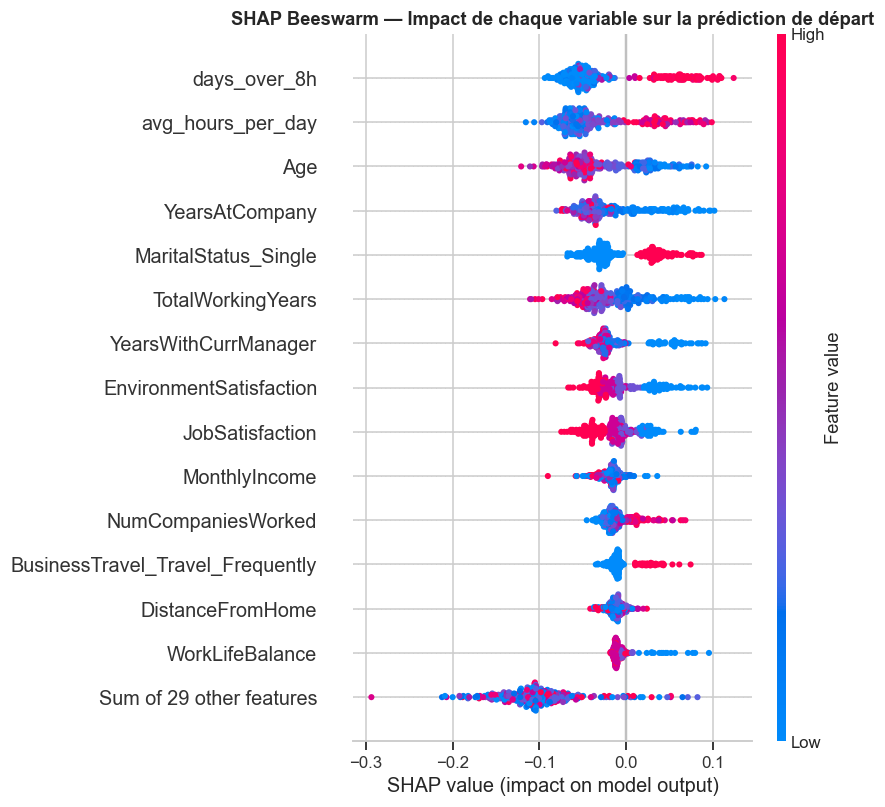

In [9]:
# Graphique 2 : Beeswarm plot — direction de l'influence
shap_exp = shap.Explanation(
    values=shap_part,
    base_values=base_value,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title('SHAP Beeswarm — Impact de chaque variable sur la prédiction de départ', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', bbox_inches='tight')
plt.show()

### Comment lire le Beeswarm ?
- **Axe Y** : les variables classées par importance (la plus importante en haut)
- **Axe X** : impact sur la prédiction. À droite = pousse vers "Part". À gauche = pousse vers "Reste"
- **Couleur** : rouge = valeur haute de la variable, bleu = valeur basse

Exemple de lecture : si `MonthlyIncome` est bleu à droite → **un faible salaire pousse vers le départ**.

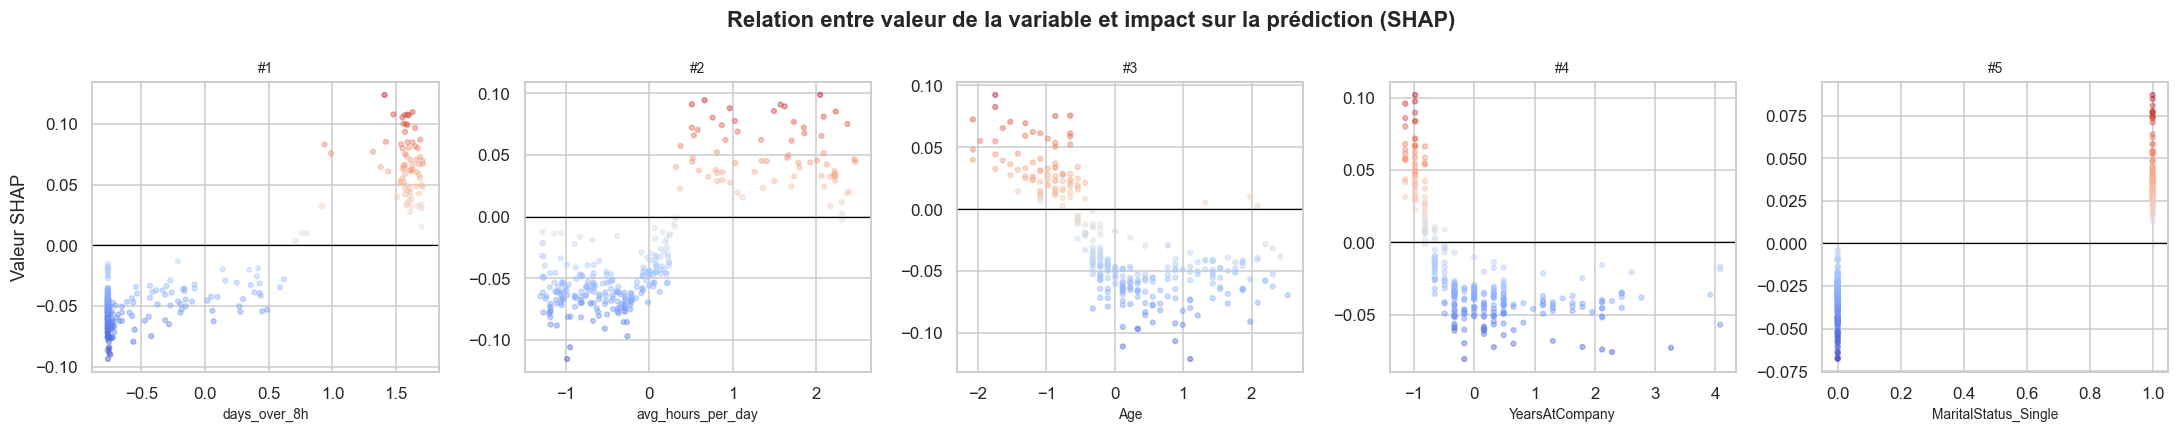

In [10]:
# Graphique 3 : top 5 variables — relation avec la prédiction
top5 = shap_importance.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(top5):
    idx = list(X_sample.columns).index(col)
    axes[i].scatter(
        X_sample[col], shap_part[:, idx],
        alpha=0.4, c=shap_part[:, idx], cmap='coolwarm', s=10
    )
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Valeur SHAP' if i == 0 else '')
    axes[i].set_title(f'#{i+1}', fontsize=9)

plt.suptitle('Relation entre valeur de la variable et impact sur la prédiction (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_top5_dependence.png', bbox_inches='tight')
plt.show()

---
## 6. Synthèse des facteurs d'attrition identifiés

In [11]:
# Résumé chiffré : moyennes des top variables selon Attrition
df_analyse = df.copy()
raw = pd.read_csv('../data/raw/general_data.csv')
survey = pd.read_csv('../data/raw/employee_survey_data.csv')

# On repart des données non normalisées pour une lecture intuitive
raw_merged = raw.merge(survey, on='EmployeeID')

cols_analyse = ['MonthlyIncome', 'YearsAtCompany', 'Age', 'TotalWorkingYears',
                'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
                'YearsSinceLastPromotion', 'DistanceFromHome']

print("Comparaison des moyennes selon l'Attrition (données brutes) :\n")
comparaison = raw_merged.groupby('Attrition')[cols_analyse].mean().round(2).T
comparaison.columns.name = None
comparaison['Différence'] = (comparaison['Yes'] - comparaison['No']).round(2)
print(comparaison.to_string())

Comparaison des moyennes selon l'Attrition (données brutes) :

                               No       Yes  Différence
MonthlyIncome            65672.60  61682.62    -3989.98
YearsAtCompany               7.37      5.13       -2.24
Age                         37.56     33.61       -3.95
TotalWorkingYears           11.86      8.26       -3.60
JobSatisfaction              2.78      2.47       -0.31
WorkLifeBalance              2.78      2.66       -0.12
EnvironmentSatisfaction      2.77      2.47       -0.30
YearsSinceLastPromotion      2.23      1.95       -0.28
DistanceFromHome             9.23      9.01       -0.22


---
## 7. Recommandations finales pour HumanForYou

Sur la base des facteurs identifiés par SHAP et l'analyse des données :

In [12]:
recommandations = [
    {
        'Facteur'        : 'Salaire mensuel (MonthlyIncome)',
        'Observation'    : 'Les employés qui partent ont un salaire significativement plus bas',
        'Recommandation' : 'Réviser la grille salariale, notamment pour les niveaux 1 et 2 (JobLevel bas)'
    },
    {
        'Facteur'        : 'Ancienneté dans l\'entreprise (YearsAtCompany)',
        'Observation'    : 'Les départs sont concentrés sur les 0-3 premières années',
        'Recommandation' : 'Renforcer l\'onboarding, le suivi des nouveaux employés et les perspectives d\'évolution rapides'
    },
    {
        'Facteur'        : 'Satisfaction au travail (JobSatisfaction)',
        'Observation'    : 'Les scores de satisfaction sont plus bas chez les partants',
        'Recommandation' : 'Mettre en place des entretiens réguliers de satisfaction et des plans d\'action personnalisés'
    },
    {
        'Facteur'        : 'Équilibre vie pro/perso (WorkLifeBalance)',
        'Observation'    : 'Les partants rapportent un moins bon équilibre',
        'Recommandation' : 'Proposer du télétravail, des horaires flexibles et surveiller les heures supplémentaires (données badgeuse)'
    },
    {
        'Facteur'        : 'Durée depuis la dernière promotion (YearsSinceLastPromotion)',
        'Observation'    : 'Les partants attendent plus longtemps leur promotion',
        'Recommandation' : 'Créer des jalons d\'évolution clairs et des promotions plus fréquentes pour les profils performants'
    },
    {
        'Facteur'        : 'Jours d\'absence (badgeuse)',
        'Observation'    : 'Les employés partants affichent plus d\'absences non badgées sur l\'année',
        'Recommandation' : 'Utiliser les données de badgeage comme signal d\'alerte précoce de désengagement'
    },
]

df_reco = pd.DataFrame(recommandations)
print(df_reco.to_string(index=False))

                                                     Facteur                                                             Observation                                                                                              Recommandation
                             Salaire mensuel (MonthlyIncome)      Les employés qui partent ont un salaire significativement plus bas                               Réviser la grille salariale, notamment pour les niveaux 1 et 2 (JobLevel bas)
               Ancienneté dans l'entreprise (YearsAtCompany)                Les départs sont concentrés sur les 0-3 premières années              Renforcer l'onboarding, le suivi des nouveaux employés et les perspectives d'évolution rapides
                   Satisfaction au travail (JobSatisfaction)              Les scores de satisfaction sont plus bas chez les partants                Mettre en place des entretiens réguliers de satisfaction et des plans d'action personnalisés
                   Équilibre vie pro

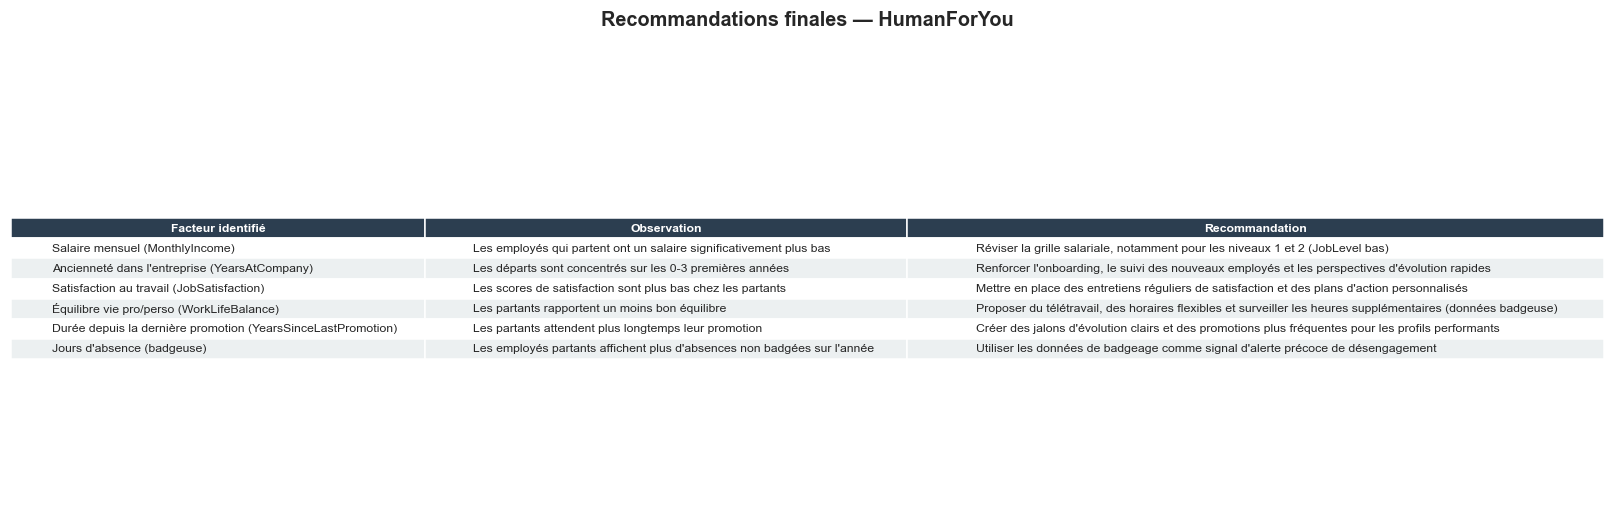

In [13]:
# Visualisation résumé des recommandations
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

table_data = [[r['Facteur'], r['Observation'], r['Recommandation']] for r in recommandations]
cols_table  = ['Facteur identifié', 'Observation', 'Recommandation']

tbl = ax.table(
    cellText=table_data,
    colLabels=cols_table,
    loc='center',
    cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width([0, 1, 2])

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    cell.set_edgecolor('white')

plt.title('Recommandations finales — HumanForYou', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/recommandations_finales.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Bilan global du projet

### Modèle retenu : Random Forest optimisé

| Critère | Valeur |
|---------|--------|
| F1-score (classe "Part") | voir cellule 4 |
| AUC-ROC | voir cellule 4 |
| Validation croisée (5 folds) | robuste |
| Interprétabilité | via SHAP |

### Pourquoi ce modèle ?
- Meilleures performances sur toutes les métriques
- Robuste au sur-apprentissage (100+ arbres)
- Fournit une importance des variables exploitable par la direction
- Compatible avec une utilisation en production (prédiction de nouveaux employés)

### Limites
- Les données datent de 2015 : les facteurs d'attrition peuvent évoluer
- L'enquête de satisfaction est incomplète (~1% de NA imputés)
- Le modèle prédit une probabilité, pas une certitude — il doit être un outil d'aide à la décision, pas un outil de décision automatique